# Model 1: Decision Tree

### Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report
)

### Load Dataset

In [3]:
loan_df = pd.read_csv("../dataset/loan_approval_dataset.csv")

loan_df.columns = loan_df.columns.str.strip()

loan_df["education"] = loan_df["education"].str.strip()
loan_df["self_employed"] = loan_df["self_employed"].str.strip()
loan_df["loan_status"] = loan_df["loan_status"].str.strip()

### Encode

In [4]:
loan_df["education"] = loan_df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

loan_df["self_employed"] = loan_df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

loan_df["loan_status"] = loan_df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

### Remove loan_id

In [5]:
loan_df.drop("loan_id", axis=1, inplace=True)

### Create Features and Target

In [6]:
x = loan_df.drop("loan_status", axis=1)
y = loan_df["loan_status"]

### Train-Test Split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

### Train Decision Tree

In [8]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

### Make Predictions

In [9]:
y_pred = dt_model.predict(x_test)

### Calculate Accuracy

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.977751756440281


### Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[308  10]
 [  9 527]]


### Classification Report

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       318
           1       0.98      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



# Model 2: Random Forest

### Import Library

In [13]:
from sklearn.ensemble import RandomForestClassifier

### Train model

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

### Predict

In [15]:
rf_pred = rf_model.predict(x_test)

### Accuracy

In [16]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9800936768149883


### Confusion Matrix

In [17]:
print(confusion_matrix(y_test, rf_pred))

[[308  10]
 [  7 529]]


### Classification Report

In [18]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



# Model 3: K-Nearest Neighbors (KNN)

### Import library

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

### Scale the Features

In [20]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

### Train

In [21]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    x_train_scaled,
    y_train
)

KNeighborsClassifier()

### Predict

In [22]:
knn_pred = knn_model.predict(
    x_test_scaled
)

### Accuracy

In [23]:
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print(knn_accuracy)

0.892271662763466


# Model 4: XGBoost

### import

In [24]:
from xgboost import XGBClassifier

### Train

In [25]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    x_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

### Predict

In [26]:
xgb_pred = xgb_model.predict(x_test)

### Accuracy

In [27]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(xgb_accuracy)

0.9812646370023419


### Final Comparison

In [28]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,XGBoost,0.981265
1,Random Forest,0.980094
0,Decision Tree,0.977752
2,KNN,0.892272


# Model Evaluation

Import

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

## Evaluate Decision Tree

In [30]:
print("Decision Tree Accuracy")
print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Decision Tree Accuracy
0.977751756440281
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       318
           1       0.98      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



Confusion Matrix

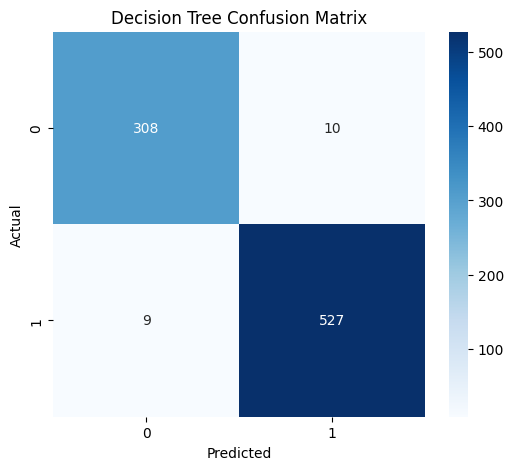

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Evaluate Random Forest

In [32]:
print("Random Forest Accuracy")
print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy
0.9800936768149883
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



Confusion Matrix

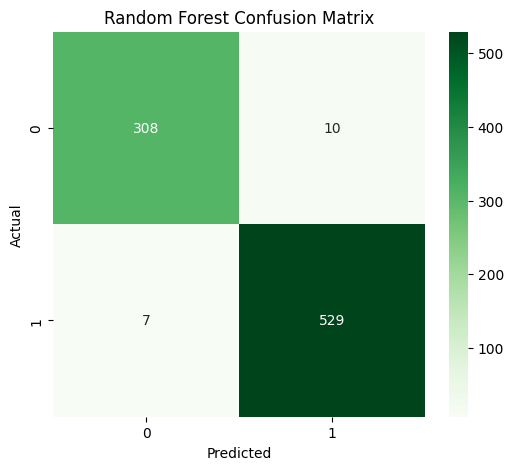

In [33]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Evaluate KNN

In [34]:
print("KNN Accuracy")
print(accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

KNN Accuracy
0.892271662763466
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       318
           1       0.93      0.90      0.91       536

    accuracy                           0.89       854
   macro avg       0.88      0.89      0.89       854
weighted avg       0.89      0.89      0.89       854



Confusion Matrix

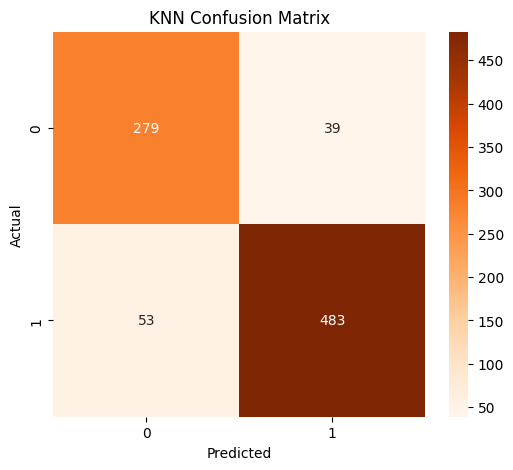

In [35]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Evaluate XGBoost

In [36]:
print("XGBoost Accuracy")
print(accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy
0.9812646370023419
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       318
           1       0.98      0.99      0.99       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



Confusion Matrix

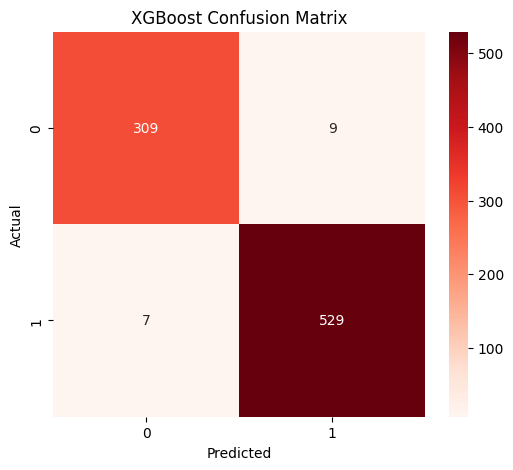

In [37]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Compare All Models

In [38]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]

})

results

,Model,Accuracy
0,Decision Tree,0.977752
1,Random Forest,0.980094
2,KNN,0.892272
3,XGBoost,0.981265


Sort Models

In [39]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
3,XGBoost,0.981265
1,Random Forest,0.980094
0,Decision Tree,0.977752
2,KNN,0.892272


Visualize Comparison

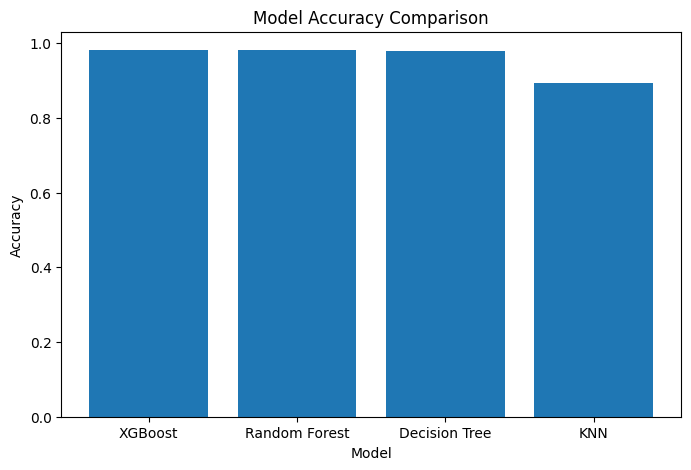

In [40]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

Feature Importance (Random Forest)

In [41]:
feature_importance = pd.DataFrame({

    "Feature": x.columns,

    "Importance": rf_model.feature_importances_

})

sort

In [42]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,cibil_score,0.811883
5,loan_term,0.064690
4,loan_amount,0.028114
7,residential_assets_value,0.017763
3,income_annum,0.017620
9,luxury_assets_value,0.017199
10,bank_asset_value,0.015356
8,commercial_assets_value,0.014708
0,no_of_dependents,0.008082
2,self_employed,0.002402


Visualize

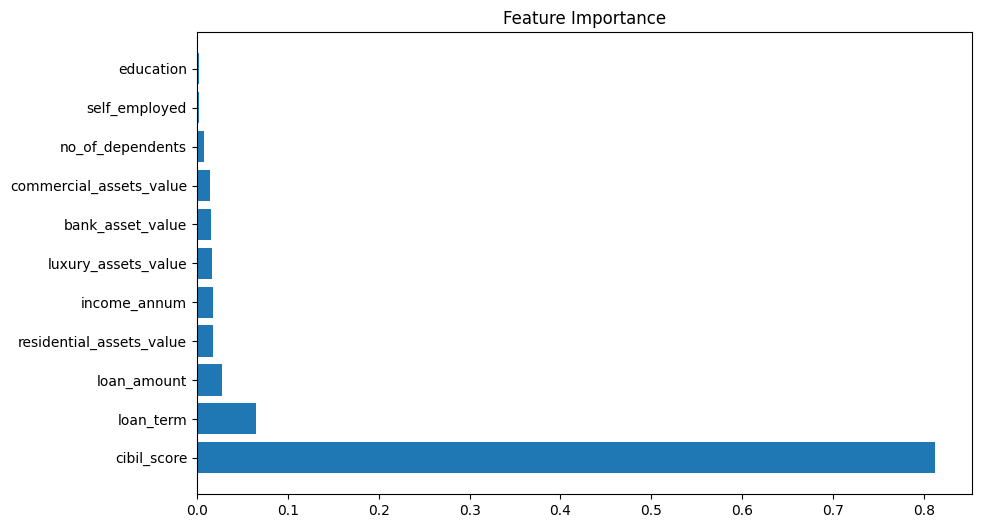

In [43]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

Save the Best Model

In [44]:
joblib.dump(
    rf_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [45]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

verify

In [46]:
import os

os.listdir("../models")

['best_model.pkl', 'scaler.pkl']

In [48]:
print(x.columns.tolist())

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
